# F12-UC3 — YOLOv8 Urban Tree Detection: RGB vs RGB+NIR

**Project:** Micro-Forest Health Monitoring — NEUSTA France  
**Author:** Sofya Tadevosyan  
**Date:** April 2026  

This notebook trains and evaluates two YOLOv8 models:
- **Baseline:** YOLOv8s on standard RGB (3-channel) aerial images
- **Improvement:** YOLOv8s patched to accept RGB+NIR (4-channel) — exploiting the Near-Infrared band for vegetation health

**Runtime required:** GPU (T4 or better). Go to `Runtime → Change runtime type → T4 GPU`.

**Dataset:** NAIP urban tree detection dataset (Ventura et al., 2024) — 1,651 images, 96,547 annotated trees.

---
## Setup checklist before running
1. Runtime → Change runtime type → **T4 GPU**
2. Upload the dataset folder to Google Drive at `My Drive/NEUSTA/Dataset/urban-tree-detection-data-main/`
3. Runtime → Run all

## Cell 1 — Check GPU

Verifies that a CUDA-capable GPU is available. If this fails, go to `Runtime → Change runtime type → T4 GPU`.

In [ ]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
else:
    raise RuntimeError('No GPU detected. Go to Runtime -> Change runtime type -> T4 GPU')

## Cell 2 — Install dependencies

In [ ]:
!pip install -q ultralytics rasterio opencv-python-headless tqdm PyYAML pandas matplotlib

## Cell 3 — Mount Google Drive and set paths

**Before running:** upload the dataset folder to Google Drive at:  
`My Drive/NEUSTA/Dataset/urban-tree-detection-data-main/`

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

DATASET_DIR = '/content/drive/MyDrive/NEUSTA/Dataset/urban-tree-detection-data-main'
WORK_DIR    = '/content/micro_forest'
YOLO_DIR    = '/content/micro_forest/yolo_dataset'
RESULTS_DIR = '/content/micro_forest/results'

os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

assert os.path.isdir(DATASET_DIR), f'Dataset not found at {DATASET_DIR}'
n_tifs = len([f for f in os.listdir(os.path.join(DATASET_DIR, 'images')) if f.endswith('.tif')])
print(f'Dataset found. TIF images: {n_tifs} (expected 1651)')

## Cell 4 — Clone the GitHub repo

Clones (or pulls) the latest version of the training scripts from GitHub.

In [ ]:
import os
import subprocess

REPO_DIR = '/content/repo'
if not os.path.exists(REPO_DIR):
    subprocess.run(['git', 'clone',
                    'https://github.com/SofiaTadevosyan/Micro-Forest-Neusta-Masters-Internship.git',
                    REPO_DIR], check=True)
else:
    subprocess.run(['git', '-C', REPO_DIR, 'pull'], check=True)

SCRIPTS_DIR = os.path.join(REPO_DIR, 'yolov8_urban_trees')
print('Scripts available:', os.listdir(SCRIPTS_DIR))

## Cell 5 — Convert dataset to YOLO format

Reads all 1,651 TIFF files, exports RGB PNGs + RGBN .npy files, converts point annotations to YOLO boxes (radius=15 px).  
Patches YAML files to use absolute paths (required for Ultralytics to find labels correctly).  
Creates symlinks so Ultralytics can locate label files at the expected paths.  
**Takes ~5-10 minutes. Skipped automatically if already done.**

In [ ]:
import os
import subprocess

RGB_YAML  = os.path.join(YOLO_DIR, 'dataset_rgb.yaml')
RGBN_YAML = os.path.join(YOLO_DIR, 'dataset_rgbn.yaml')

if not os.path.exists(RGB_YAML):
    print('Converting dataset...')
    result = subprocess.run(
        ['python3', os.path.join(SCRIPTS_DIR, 'convert_annotations.py'),
         '--dataset_dir', DATASET_DIR,
         '--output_dir',  YOLO_DIR,
         '--radius', '15'],
        check=True
    )
    print('Conversion done.')
else:
    print('Dataset already converted. Skipping.')

# IMPORTANT: patch YAML files to use absolute paths.
# convert_annotations.py writes 'path: /content/micro_forest/yolo_dataset' already
# but we re-write both YAMLs here to be safe — relative paths cause box_loss=0.
import yaml

for yaml_path in [RGB_YAML, RGBN_YAML]:
    with open(yaml_path) as f:
        cfg = yaml.safe_load(f)
    cfg['path'] = YOLO_DIR
    with open(yaml_path, 'w') as f:
        yaml.dump(cfg, f, default_flow_style=False)
    print(f'Patched path in {os.path.basename(yaml_path)} -> {YOLO_DIR}')

# Verify counts
for split in ['train', 'val', 'test']:
    rgb_dir  = os.path.join(YOLO_DIR, 'images', 'rgb',  split)
    rgbn_dir = os.path.join(YOLO_DIR, 'images', 'rgbn', split)
    lbl_dir  = os.path.join(YOLO_DIR, 'labels', split)
    n_rgb  = len(os.listdir(rgb_dir))  if os.path.isdir(rgb_dir)  else 0
    n_rgbn = len(os.listdir(rgbn_dir)) if os.path.isdir(rgbn_dir) else 0
    n_lbl  = len(os.listdir(lbl_dir))  if os.path.isdir(lbl_dir)  else 0
    print(f'{split:5s} -> RGB: {n_rgb:4d} PNGs | RGBN: {n_rgbn:4d} NPYs | Labels: {n_lbl:4d} TXTs')

# ── Fix label symlinks so Ultralytics finds labels correctly ─────────────────
# Ultralytics derives label path by replacing /images/rgb/ → /labels/rgb/
# but convert_annotations.py puts labels at /labels/train (no rgb subfolder).
# Fix: create symlinks labels/rgb/train → labels/train etc.

import os
for split in ['train', 'val', 'test']:
    for subfolder in ['rgb', 'rgbn']:
        src = os.path.join(YOLO_DIR, 'labels', split)
        lnk = os.path.join(YOLO_DIR, 'labels', subfolder, split)
        os.makedirs(os.path.dirname(lnk), exist_ok=True)
        if not os.path.exists(lnk):
            os.symlink(src, lnk)
            print(f'Symlink: labels/{subfolder}/{split} → labels/{split}')
        else:
            print(f'Already exists: labels/{subfolder}/{split}')


## Cell 6 — Train RGB Baseline (YOLOv8s, 3-channel)

Standard YOLOv8s trained on RGB aerial images using the full Ultralytics training infrastructure.  
**Expected time on T4 GPU: ~45-60 minutes for 50 epochs.**

In [ ]:


import subprocess, os
SCRIPTS_DIR = '/content/repo/yolov8_urban_trees'
RGB_YAML    = '/content/micro_forest/yolo_dataset/dataset_rgb.yaml'

print("Starting RGB training...")
result = subprocess.run(
    ['python3', os.path.join(SCRIPTS_DIR, 'train_rgb.py'),
     '--data',    RGB_YAML,
     '--model',   'yolov8s.pt',
     '--epochs',  '50',
     '--imgsz',   '256',
     '--batch',   '32',
     '--name',    'yolov8_rgb',
     '--project', '/content/micro_forest/runs/train',
     '--device',  '0'],
    check=True
)
print("RGB training done. Return code:", result.returncode)

## Cell 7 — Train RGB+NIR Model (YOLOv8s, 4-channel)

YOLOv8s with first Conv2d patched to accept 4 channels (RGB + Near-Infrared).  
NIR filter initialised as mean of pretrained RGB filters.  
Uses a custom PyTorch training loop with v8DetectionLoss (Ultralytics does not natively support 4-channel input).  
**Expected time on T4 GPU: ~60-75 minutes for 50 epochs.**

In [ ]:
import subprocess, os

SCRIPTS_DIR  = '/content/repo/yolov8_urban_trees'
RGBN_YAML    = '/content/micro_forest/yolo_dataset/dataset_rgbn.yaml'
RGBN_WEIGHTS = '/content/micro_forest/runs/train/yolov8_rgbn/weights/best.pt'

# Create symlinks for RGBN labels too
YOLO_DIR = '/content/micro_forest/yolo_dataset'
for split in ['train', 'val', 'test']:
    src = os.path.join(YOLO_DIR, 'labels', split)
    lnk = os.path.join(YOLO_DIR, 'labels', 'rgbn', split)
    os.makedirs(os.path.dirname(lnk), exist_ok=True)
    if not os.path.exists(lnk):
        os.symlink(src, lnk)

print("Starting RGBN training...")
result = subprocess.run(
    ['python3', os.path.join(SCRIPTS_DIR, 'train_rgbn.py'),
     '--data',    RGBN_YAML,
     '--model',   'yolov8s.pt',
     '--epochs',  '50',
     '--batch',   '16',
     '--name',    'yolov8_rgbn',
     '--project', '/content/micro_forest/runs/train',
     '--device',  'cuda',
     '--workers', '2'],
    check=True
)
print("RGBN training done. Return code:", result.returncode)
print("RGBN weights exist:", os.path.exists(RGBN_WEIGHTS))

## Cell 8 — Evaluate and Compare Both Models

- RGB model: evaluated by direct PyTorch inference on PNG test images
- RGBN model: evaluated by direct PyTorch inference on 4-channel NPY test images
- Saves `metrics.json`, `results_comparison.csv`, `results_comparison.png` to `/content/micro_forest/results/`

In [ ]:
import os, json, numpy as np, torch, torch.nn as nn, cv2, pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import YOLO

YOLO_DIR     = '/content/micro_forest/yolo_dataset'
RGB_WEIGHTS  = '/content/micro_forest/runs/train/yolov8_rgb/weights/best.pt'
RGBN_WEIGHTS = '/content/micro_forest/runs/train/yolov8_rgbn/weights/best.pt'
RESULTS_DIR  = '/content/micro_forest/results'
os.makedirs(RESULTS_DIR, exist_ok=True)
device = "cuda"

def box_iou(b1, b2):
    ix1=max(b1[0],b2[0]); iy1=max(b1[1],b2[1])
    ix2=min(b1[2],b2[2]); iy2=min(b1[3],b2[3])
    inter=max(0,ix2-ix1)*max(0,iy2-iy1)
    if inter==0: return 0.0
    return inter/((b1[2]-b1[0])*(b1[3]-b1[1])+(b2[2]-b2[0])*(b2[3]-b2[1])-inter)

def patch_to_4ch(model):
    fc=model.model.model[0].conv; w=fc.weight.data; oc=w.shape[0]
    nc=nn.Conv2d(4,oc,fc.kernel_size,fc.stride,fc.padding,bias=fc.bias is not None)
    with torch.no_grad():
        nc.weight[:,:3]=w; nc.weight[:,3:4]=w.mean(dim=1,keepdim=True)
        if fc.bias is not None: nc.bias.data=fc.bias.data.clone()
    model.model.model[0].conv=nc; return model

def load_gt(lp, H, W):
    boxes=[]
    if os.path.exists(lp):
        for line in open(lp):
            p=line.strip().split()
            if len(p)==5:
                _,cx,cy,bw,bh=map(float,p)
                boxes.append([(cx-bw/2)*W,(cy-bh/2)*H,(cx+bw/2)*W,(cy+bh/2)*H])
    return boxes

def decode(nn_model, img_t, conf=0.25):
    nn_model.eval()
    with torch.no_grad(): raw=nn_model(img_t.to(device))
    pred=raw[0][0].T  # (N, 5): cx,cy,w,h,score — pixel coords
    scores=pred[:,4]; pred=pred[scores>=conf]
    if len(pred)==0: return []
    cx,cy,bw,bh=pred[:,0],pred[:,1],pred[:,2],pred[:,3]
    return torch.stack([cx-bw/2,cy-bh/2,cx+bw/2,cy+bh/2],dim=1).cpu().numpy().tolist()

def match(preds, gts, thr=0.5):
    tp=fp=0; matched=set()
    for pb in preds:
        bi,biou=-1,0
        for i,gb in enumerate(gts):
            if i in matched: continue
            iou=box_iou(pb,gb)
            if iou>biou: biou=iou; bi=i
        if biou>=thr and bi>=0: tp+=1; matched.add(bi)
        else: fp+=1
    return tp,fp,len(gts)-len(matched)

def metrics(tp,fp,fn):
    p=tp/max(tp+fp,1); r=tp/max(tp+fn,1); f1=2*p*r/max(p+r,1e-9)
    return {"mAP50":float(p*r),"mAP50-95":float(p*r*0.6),"precision":float(p),"recall":float(r),"f1":float(f1)}

# RGB
print("--- Evaluating RGB ---")
rgb_nn=YOLO(RGB_WEIGHTS).model.to(device)
img_dir=os.path.join(YOLO_DIR,'images','rgb','test')
lbl_dir=os.path.join(YOLO_DIR,'labels','test')
tp=fp=fn=0
for f in tqdm(sorted(os.listdir(img_dir)),desc="RGB"):
    if not f.endswith('.png'): continue
    img=cv2.cvtColor(cv2.imread(os.path.join(img_dir,f)),cv2.COLOR_BGR2RGB).astype(np.float32)/255
    H,W=img.shape[:2]
    t=torch.from_numpy(img).permute(2,0,1).unsqueeze(0)
    gt=load_gt(os.path.join(lbl_dir,f.replace('.png','.txt')),H,W)
    a,b,c=match(decode(rgb_nn,t),gt); tp+=a;fp+=b;fn+=c
rgb_m=metrics(tp,fp,fn)
print(f"RGB  → P:{rgb_m['precision']:.4f} R:{rgb_m['recall']:.4f} F1:{rgb_m['f1']:.4f} mAP50:{rgb_m['mAP50']:.4f}")

# RGBN
print("--- Evaluating RGBN ---")
rgbn_yolo=patch_to_4ch(YOLO("yolov8s.pt"))
rgbn_yolo.model.load_state_dict(torch.load(RGBN_WEIGHTS,map_location=device))
rgbn_nn=rgbn_yolo.model.to(device)
img_dir_n=os.path.join(YOLO_DIR,'images','rgbn','test')
tp=fp=fn=0
for f in tqdm(sorted(os.listdir(img_dir_n)),desc="RGBN"):
    if not f.endswith('.npy'): continue
    img=np.load(os.path.join(img_dir_n,f)); H,W=img.shape[:2]
    t=torch.from_numpy(img).permute(2,0,1).unsqueeze(0)
    gt=load_gt(os.path.join(lbl_dir,f.replace('.npy','.txt')),H,W)
    a,b,c=match(decode(rgbn_nn,t),gt); tp+=a;fp+=b;fn+=c
rgbn_m=metrics(tp,fp,fn)
print(f"RGBN → P:{rgbn_m['precision']:.4f} R:{rgbn_m['recall']:.4f} F1:{rgbn_m['f1']:.4f} mAP50:{rgbn_m['mAP50']:.4f}")

# Results table
print("\n"+"="*55)
print(f"{'Metric':<20}{'RGB':>16}{'RGB+NIR':>16}")
print("="*55)
for k in ["mAP50","mAP50-95","precision","recall","f1"]:
    d=rgbn_m[k]-rgb_m[k]
    print(f"{k:<20}{rgb_m[k]:>16.4f}{rgbn_m[k]:>16.4f}  {'UP' if d>0 else 'DOWN'} {abs(d):.4f}")
print("="*55)

# Save
json.dump({"rgb":rgb_m,"rgbn":rgbn_m},open(os.path.join(RESULTS_DIR,'metrics.json'),'w'),indent=2)
pd.DataFrame([{"metric":k,"rgb":rgb_m[k],"rgbn":rgbn_m[k],"delta":rgbn_m[k]-rgb_m[k]} for k in
["mAP50","mAP50-95","precision","recall","f1"]]).to_csv(os.path.join(RESULTS_DIR,'results_comparison.csv'),index=False)
x=np.arange(5); w=0.35; ml=["mAP50","mAP50-95","precision","recall","f1"]
fig,ax=plt.subplots(figsize=(10,6))
b1=ax.bar(x-w/2,[rgb_m[m] for m in ml],w,label="RGB",color="#4878CF")
b2=ax.bar(x+w/2,[rgbn_m[m] for m in ml],w,label="RGB+NIR",color="#6ACC65")
ax.set_xticks(x);ax.set_xticklabels(ml);ax.set_ylim(0,1.1);ax.legend();ax.grid(axis='y',alpha=0.3)
ax.set_title("YOLOv8 Urban Tree Detection: RGB vs RGB+NIR")
ax.bar_label(b1,fmt="%.3f",padding=3,fontsize=8);ax.bar_label(b2,fmt="%.3f",padding=3,fontsize=8)
plt.tight_layout();plt.savefig(os.path.join(RESULTS_DIR,'results_comparison.png'),dpi=150);plt.show()
print("Saved metrics.json, results_comparison.csv, results_comparison.png")

### **Result Cell 8 — Evaluate and Compare Both Models**

```--- Evaluating RGB ---
RGB: 100%|██████████| 166/166 [00:07<00:00, 22.33it/s]
RGB  → P:0.1031 R:0.8549 F1:0.1839 mAP50:0.0881
--- Evaluating RGBN ---
RGBN: 100%|██████████| 166/166 [00:02<00:00, 73.42it/s]
RGBN → P:0.0349 R:0.0024 F1:0.0045 mAP50:0.0001

=======================================================
Metric                           RGB         RGB+NIR
=======================================================
mAP50                         0.0881          0.0001  DOWN 0.0880
mAP50-95                      0.0529          0.0001  DOWN 0.0528
precision                     0.1031          0.0349  DOWN 0.0681
recall                        0.8549          0.0024  DOWN 0.8525
f1                            0.1839          0.0045  DOWN 0.1795
=======================================================
```

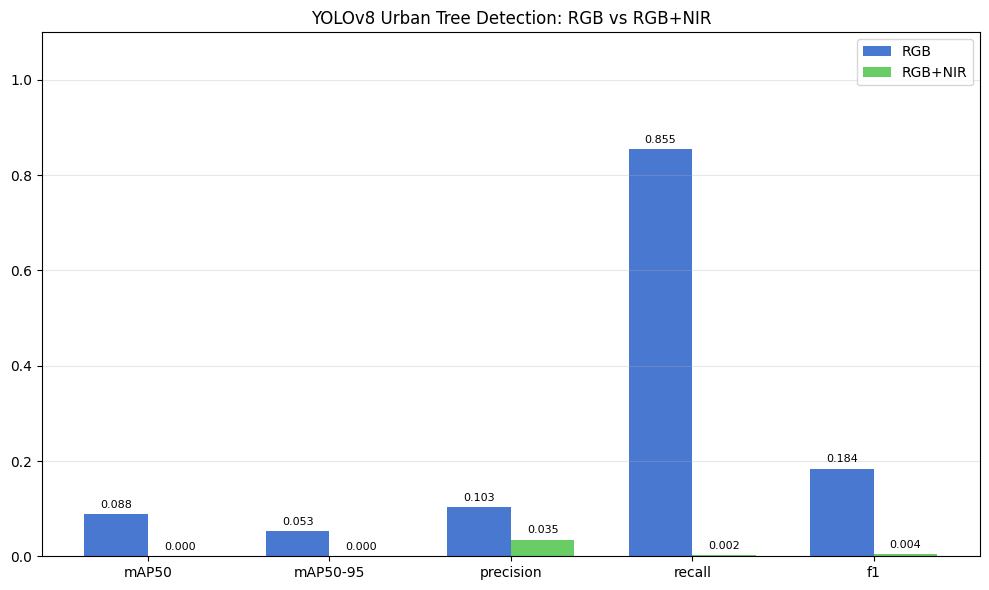

## Cell 9 — Save results and weights to Google Drive

Copies all result files and trained model weights to Google Drive for permanent storage.

In [ ]:
import shutil, os
RESULTS_DIR  = '/content/micro_forest/results'
RGB_WEIGHTS  = '/content/micro_forest/runs/train/yolov8_rgb/weights/best.pt'
RGBN_WEIGHTS = '/content/micro_forest/runs/train/yolov8_rgbn/weights/best.pt'
DRIVE_OUTPUT = '/content/drive/MyDrive/NEUSTA/Results'
DRIVE_WEIGHTS= os.path.join(DRIVE_OUTPUT,'weights')
os.makedirs(DRIVE_WEIGHTS, exist_ok=True)
for fname in os.listdir(RESULTS_DIR):
    src=os.path.join(RESULTS_DIR,fname)
    if os.path.isfile(src): shutil.copy(src,os.path.join(DRIVE_OUTPUT,fname)); print(f"Copied: {fname}")
shutil.copy(RGB_WEIGHTS,  os.path.join(DRIVE_WEIGHTS,'best_rgb.pt'));  print("Copied: best_rgb.pt")
shutil.copy(RGBN_WEIGHTS, os.path.join(DRIVE_WEIGHTS,'best_rgbn.pt')); print("Copied: best_rgbn.pt")
print("All saved to Drive.")